#  — Análisis Completo de Riesgo
## Pares de divisas · Datos reales EOD API · VaR · ES · GARCH · Ratios

---

### ¿Qué es el Risk Management en Forex?

El mercado de divisas (Forex) es el más líquido del mundo, a diferencia de la bolsa, opera **24 horas al día, 5 días a la semana**, y los movimientos de precio, aunque en apariencia pequeños (pips), pueden generar pérdidas enormes si se usa apalancamiento.

**El Risk Management responde a estas preguntas:**
- ¿Cuánto puedo perder mañana con un 99% de confianza? → **VaR**
- Si ocurre lo peor, ¿cuánto perdería en promedio? → **ES / CVaR**
- ¿Cuánta volatilidad tiene este par hoy vs ayer? → **GARCH**
- ¿Este par compensa el riesgo que asumo? → **Sharpe / Sortino**
- ¿Cuál ha sido la peor racha de pérdidas históricamente? → **Max Drawdown**
- ¿Qué pares son más seguros en este momento? → **Filtrador por riesgo**

---

| Bloque | Contenido |
|--------|-----------|
| **0** | Instalación + descarga de datos (desplegable de pares) |
| **1** | Análisis descriptivo: precios, rendimientos, estadísticos |
| **2** | Volatilidad: r², MM5, RM094, GARCH-GJR |
| **3** | VaR y ES: Histórico, Paramétrico, Monte Carlo |
| **4** | Drawdown máximo, Sharpe, Sortino, Calmar |
| **5** | Correlaciones entre pares |
| **6** | Filtrador de pares por riesgo (ranking) |
| **7** |  Dashboard visual completo |

##  — Instalación y descarga de datos


**Categorías de pares:**
| Categoría | Ejemplos | Características |
|-----------|----------|----------------|
| **Majors** | EUR/USD, GBP/USD, USD/JPY | Mayor liquidez, menor spread, menos volátiles |
| **Minors** | EUR/GBP, AUD/CAD, NZD/USD | Liquidez media, spreads moderados |
| **Exóticos** | USD/MXN, USD/TRY, USD/ZAR | Menor liquidez, muy volátiles, spreads altos |

In [1]:
!pip install arch requests ipywidgets scipy statsmodels matplotlib seaborn pandas numpy -q
print('✅ Librerías instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.5 MB/s eta 0:00:00
✅ Librerías instaladas.


In [2]:
import requests, warnings, datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t as t_dist
from arch import arch_model
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

# ── Configuración ────────────────────────────────────────────────
API_KEY    = '69b4102fe03158.38387378'
END_DATE   = datetime.date.today().strftime('%Y-%m-%d')
START_DATE = (datetime.date.today() - datetime.timedelta(days=365*10+10)).strftime('%Y-%m-%d')

# ── Catálogo de pares Forex disponibles en EOD ───────────────────
FOREX_PAIRS = {
    # ── MAJORS ──────────────────────────────────────────────────
    '🟢 EUR/USD  (Euro / Dólar)':           'EURUSD',
    '🟢 GBP/USD  (Libra / Dólar)':          'GBPUSD',
    '🟢 USD/JPY  (Dólar / Yen)':            'USDJPY',
    '🟢 USD/CHF  (Dólar / Franco suizo)':   'USDCHF',
    '🟢 AUD/USD  (Dólar australiano)':      'AUDUSD',
    '🟢 USD/CAD  (Dólar canadiense)':       'USDCAD',
    '🟢 NZD/USD  (Dólar neozelandés)':      'NZDUSD',
    # ── MINORS ──────────────────────────────────────────────────
    '🟡 EUR/GBP  (Euro / Libra)':           'EURGBP',
    '🟡 EUR/JPY  (Euro / Yen)':             'EURJPY',
    '🟡 EUR/CHF  (Euro / Franco suizo)':    'EURCHF',
    '🟡 GBP/JPY  (Libra / Yen)':            'GBPJPY',
    '🟡 AUD/JPY  (Dólar aus. / Yen)':       'AUDJPY',
    '🟡 AUD/CAD  (Dólar aus. / CAD)':       'AUDCAD',
    '🟡 CAD/JPY  (CAD / Yen)':              'CADJPY',
    '🟡 NZD/JPY  (NZD / Yen)':              'NZDJPY',
    '🟡 GBP/CHF  (Libra / Franco)':         'GBPCHF',
    # ── EXÓTICOS ────────────────────────────────────────────────
    '🔴 USD/MXN  (Dólar / Peso mexicano)':  'USDMXN',
    '🔴 USD/TRY  (Dólar / Lira turca)':     'USDTRY',
    '🔴 USD/ZAR  (Dólar / Rand sudafr.)':   'USDZAR',
    '🔴 USD/BRL  (Dólar / Real brasileño)': 'USDBRL',
    '🔴 USD/SEK  (Dólar / Corona sueca)':   'USDSEK',
    '🔴 USD/NOK  (Dólar / Corona noruega)': 'USDNOK',
    '🔴 EUR/TRY  (Euro / Lira turca)':      'EURTRY',
    '🔴 USD/SGD  (Dólar / Dólar sing.)':    'USDSGD',
    '🔴 USD/HKD  (Dólar / Dólar HK)':       'USDHKD',
}

# ── Widgets de selección ─────────────────────────────────────────
dd_single = widgets.Dropdown(
    options=list(FOREX_PAIRS.keys()),
    value='🟢 EUR/USD  (Euro / Dólar)',
    description='Par principal:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

multi_select = widgets.SelectMultiple(
    options=list(FOREX_PAIRS.keys()),
    value=['🟢 EUR/USD  (Euro / Dólar)', '🟢 GBP/USD  (Libra / Dólar)',
           '🟢 USD/JPY  (Dólar / Yen)',  '🟢 AUD/USD  (Dólar australiano)'],
    description='Pares (multi):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px', height='180px')
)

btn_dl   = widgets.Button(description='📥 Descargar datos',
                           button_style='success',
                           layout=widgets.Layout(width='180px', height='40px'))
out_dl   = widgets.Output()
G        = {}   # diccionario global compartido entre bloques

def fetch_forex(symbol):
    """Descarga datos diarios de un par Forex via EOD API"""
    url = f'https://eodhistoricaldata.com/api/eod/{symbol}.FOREX'
    params = {'api_token': API_KEY, 'from': START_DATE,
              'to': END_DATE, 'fmt': 'json', 'period': 'd'}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    if not data:
        raise ValueError(f'Sin datos para {symbol}')
    df = pd.DataFrame(data)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')[['close']].rename(columns={'close': 'price'})
    df['return'] = np.log(df['price'] / df['price'].shift(1))
    return df.dropna()

def on_download(b):
    with out_dl:
        clear_output()
        G.clear()
        main_name   = dd_single.value
        main_symbol = FOREX_PAIRS[main_name]
        multi_names = list(multi_select.value)
        all_names   = list(dict.fromkeys([main_name] + multi_names))

        print(f'📅 Período: {START_DATE}  →  {END_DATE}  (~10 años)')
        print(f'{'─'*55}')

        G['multi'] = {}
        for name in all_names:
            sym = FOREX_PAIRS[name]
            try:
                df = fetch_forex(sym)
                G['multi'][name] = df
                flag = '✅' if name == main_name else '  '
                print(f'{flag} {name:<45} {len(df):>5} obs  |  '
                      f'{df.index[0].date()} → {df.index[-1].date()}')
            except Exception as e:
                print(f'  ❌ {name}: {e}')

        if main_name in G['multi']:
            G['main_name']   = main_name
            G['main_symbol'] = main_symbol
            G['df']          = G['multi'][main_name]
            print(f'\n✅ Par principal cargado: {main_name}')
            print(f'   Precio actual: {G["df"]["price"].iloc[-1]:.5f}')
            print(f'   Rendimiento medio diario: {G["df"]["return"].mean()*100:.4f}%')
            print(f'   Volatilidad diaria (sd):  {G["df"]["return"].std()*100:.4f}%')
        else:
            print('❌ No se pudo cargar el par principal.')

btn_dl.on_click(on_download)
display(HTML('<h3>Selecciona tu par principal y los pares para comparar:</h3>'))
display(HTML('<i>🟢 Major · 🟡 Minor · 🔴 Exótico</i><br>'))
display(HTML('<b>Par principal (análisis individual):</b>'))
display(dd_single)
display(HTML('<br><b>Pares para ranking y correlaciones (Ctrl+Click para seleccionar varios):</b>'))
display(multi_select)
display(HTML('<br>'))
display(btn_dl)
display(out_dl)

Dropdown(description='Par principal:', layout=Layout(width='420px'), options=('🟢 EUR/USD  (Euro / Dólar)', '🟢 …

SelectMultiple(description='Pares (multi):', index=(0, 1, 2, 4), layout=Layout(height='180px', width='420px'),…

Button(button_style='success', description='📥 Descargar datos', layout=Layout(height='40px', width='180px'), s…

Output()

---
## — Análisis Descriptivo del Par

### ¿Por qué analizamos los rendimientos y no el precio?

En Forex, el precio absoluto no tiene mucho significado estadístico (EUR/USD cotiza ~1.08 siempre). Lo que importa es el **rendimiento logarítmico diario**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Los rendimientos tienen propiedades útiles:
- **Aditividad temporal**: r_semana ≈ r_lun + r_mar + r_mié + r_jue + r_vie
- **Estacionariedad**: su media y varianza son estables en el tiempo
- **Comparabilidad**: podemos comparar EUR/USD con USD/JPY directamente

### Estadísticos clave en Forex:
| Estadístico | Qué nos dice | Valor típico Forex |
|-------------|-------------|-------------------|
| **DT (sigma)** | Volatilidad histórica | 0.3%–0.8% diario en majors |
| **Asimetría** | Si hay más pérdidas que ganancias extremas | Cerca de 0 |
| **Curtosis** | Si los eventos extremos son frecuentes | >3 (colas pesadas) |
| **JB test** | Si la distribución es Normal | Casi siempre rechaza en Forex |

📋 ESTADÍSTICOS DESCRIPTIVOS — 🟢 EUR/USD  (Euro / Dólar) (EURUSD)
  Observaciones        : 3192
  Media diaria (μ)     : 0.0000079  (0.00079%)
  Desv. típica (σ)     : 0.0045354  (0.45354%)
  Vol. anualizada      : 7.1998%
  Asimetría            : 0.0782  (0 = simétrica)
  Curtosis total       : 5.3091  (3 = Normal; >3 = colas pesadas)
  Jarque-Bera          : 709.03   p-valor: 1.08e-154
  Mínimo (peor día)    : -2.6850%  el 2016-06-26
  Máximo (mejor día)   : 2.2936%  el 2025-04-09
  ❌ No es Normal (JB p<0.05) → justifica usar t-Student en VaR

  💡 Volatilidad anualizada 7.20%:
     → Volatilidad MODERADA (minors o pares con JPY)


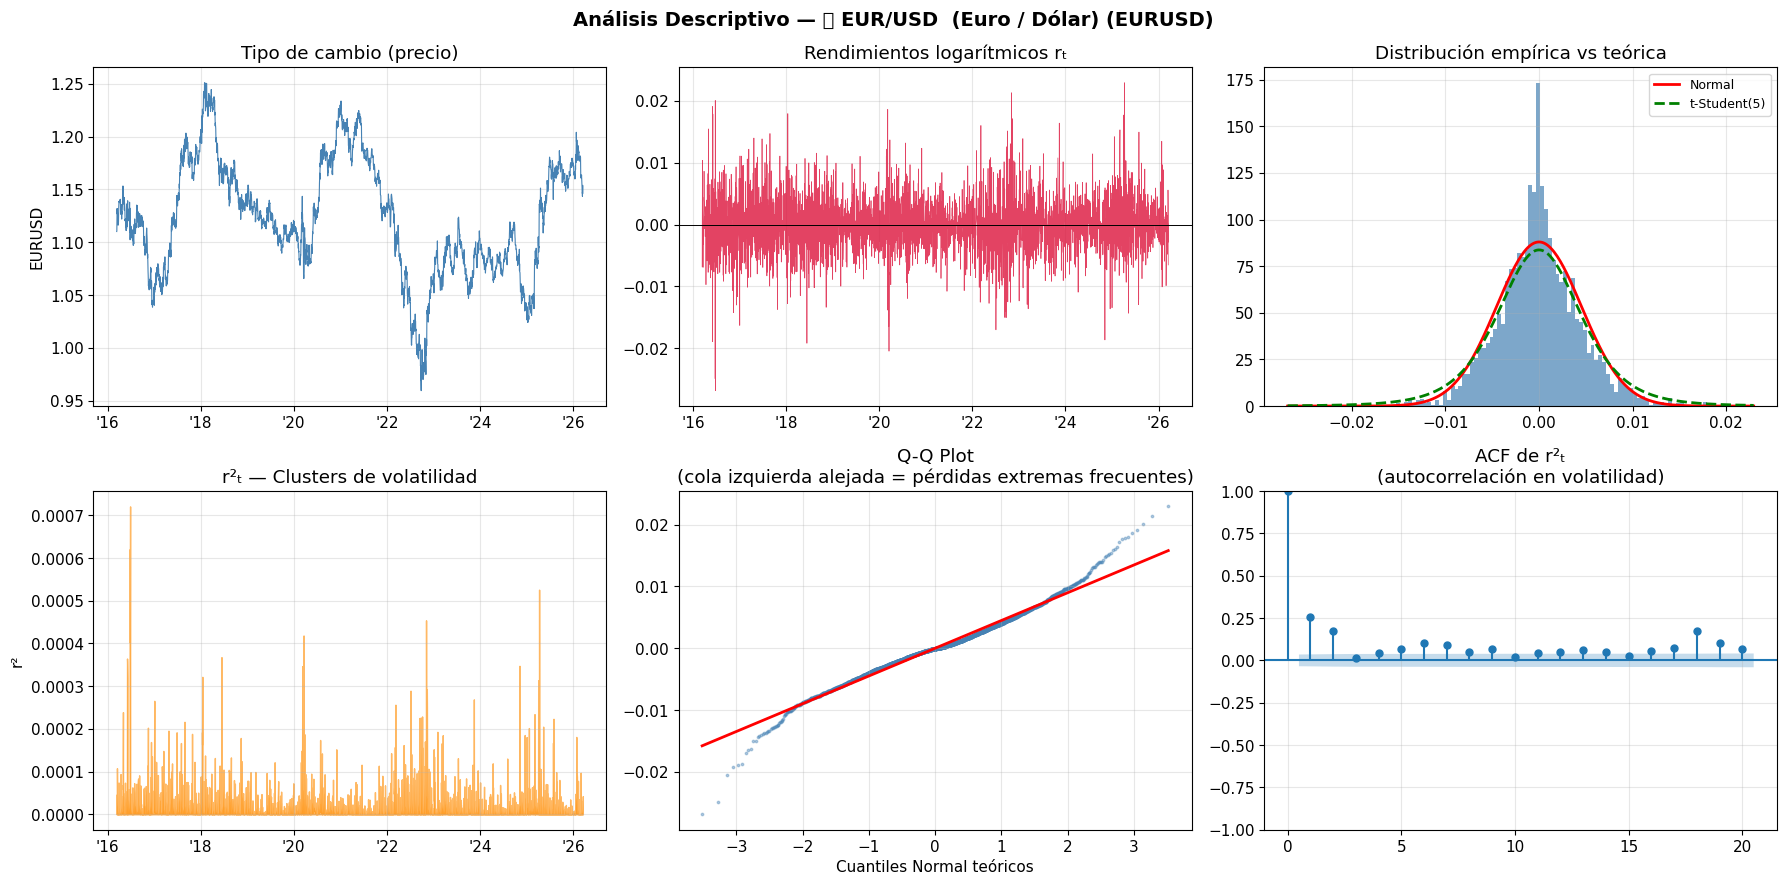


💡 LECTURA DEL Q-Q PLOT EN FOREX:
   Si los puntos se alejan de la línea roja en los extremos,
   significa que los movimientos extremos del tipo de cambio
   son MÁS frecuentes de lo que predice la distribución Normal.
   → Esto justifica usar t-Student o modelos GARCH para el VaR.


In [3]:
if not G or 'df' not in G:
    print('⚠️  Ejecuta el paso 0 primero.')
else:
    df     = G['df']
    r      = df['return']
    name   = G['main_name']
    symbol = G['main_symbol']

    # ── Estadísticos ─────────────────────────────────────────────
    mu      = r.mean()
    sigma   = r.std()
    sk      = r.skew()
    ku      = r.kurtosis() + 3   # curtosis total (no exceso)
    jb, jpv = stats.jarque_bera(r)
    T       = len(r)

    G['mu']    = mu
    G['sigma'] = sigma
    G['T']     = T
    G['sq_r']  = r**2

    print(f'📋 ESTADÍSTICOS DESCRIPTIVOS — {name} ({symbol})')
    print('='*60)
    print(f'  Observaciones        : {T}')
    print(f'  Media diaria (μ)     : {mu:.7f}  ({mu*100:.5f}%)')
    print(f'  Desv. típica (σ)     : {sigma:.7f}  ({sigma*100:.5f}%)')
    print(f'  Vol. anualizada      : {sigma*np.sqrt(252)*100:.4f}%')
    print(f'  Asimetría            : {sk:.4f}  (0 = simétrica)')
    print(f'  Curtosis total       : {ku:.4f}  (3 = Normal; >3 = colas pesadas)')
    print(f'  Jarque-Bera          : {jb:.2f}   p-valor: {jpv:.2e}')
    print(f'  Mínimo (peor día)    : {r.min()*100:.4f}%  el {r.idxmin().date()}')
    print(f'  Máximo (mejor día)   : {r.max()*100:.4f}%  el {r.idxmax().date()}')
    print('='*60)

    if jpv < 0.05:
        print('  ❌ No es Normal (JB p<0.05) → justifica usar t-Student en VaR')
    else:
        print('  ✅ No rechazamos normalidad')

    print(f'\n  💡 Volatilidad anualizada {sigma*np.sqrt(252)*100:.2f}%:')
    if sigma*np.sqrt(252) < 0.06:
        print('     → Par POCO volátil (típico de majors estables como EUR/USD)')
    elif sigma*np.sqrt(252) < 0.12:
        print('     → Volatilidad MODERADA (minors o pares con JPY)')
    else:
        print('     → Par MUY VOLÁTIL (exóticos con elevado riesgo de tipo de cambio)')

    # ── GRÁFICOS ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle(f'Análisis Descriptivo — {name} ({symbol})',
                 fontsize=14, fontweight='bold')

    # 1. Precio
    axes[0,0].plot(df.index, df['price'], color='steelblue', lw=0.8)
    axes[0,0].set_title('Tipo de cambio (precio)')
    axes[0,0].set_ylabel(symbol)
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 2. Rendimientos
    axes[0,1].plot(df.index, r, color='crimson', lw=0.5, alpha=0.8)
    axes[0,1].axhline(0, color='black', lw=0.7)
    axes[0,1].set_title('Rendimientos logarítmicos rₜ')
    axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 3. Histograma
    axes[0,2].hist(r, bins=120, color='steelblue', alpha=0.7, density=True)
    xr = np.linspace(r.min(), r.max(), 300)
    axes[0,2].plot(xr, norm.pdf(xr, mu, sigma), 'r-', lw=2, label='Normal')
    axes[0,2].plot(xr, t_dist.pdf((xr-mu)/sigma, df=5)/sigma,
                   'g--', lw=2, label='t-Student(5)')
    axes[0,2].set_title('Distribución empírica vs teórica')
    axes[0,2].legend(fontsize=9)

    # 4. r² (clusters de volatilidad)
    axes[1,0].fill_between(df.index, r**2, color='darkorange', alpha=0.6)
    axes[1,0].set_title('r²ₜ — Clusters de volatilidad')
    axes[1,0].set_ylabel('r²')
    axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 5. Q-Q Plot
    (osm, osr), (sl, ic, _) = stats.probplot(r, dist='norm')
    axes[1,1].scatter(osm, osr, s=3, alpha=0.4, color='steelblue')
    axes[1,1].plot(osm, sl*np.array(osm)+ic, 'r-', lw=2)
    axes[1,1].set_title('Q-Q Plot\n(cola izquierda alejada = pérdidas extremas frecuentes)')
    axes[1,1].set_xlabel('Cuantiles Normal teóricos')

    # 6. ACF rendimientos
    sm.graphics.tsa.plot_acf(r**2, lags=20, ax=axes[1,2],
                              title='ACF de r²ₜ\n(autocorrelación en volatilidad)')

    plt.tight_layout()
    plt.show()

    print('\n💡 LECTURA DEL Q-Q PLOT EN FOREX:')
    print('   Si los puntos se alejan de la línea roja en los extremos,')
    print('   significa que los movimientos extremos del tipo de cambio')
    print('   son MÁS frecuentes de lo que predice la distribución Normal.')
    print('   → Esto justifica usar t-Student o modelos GARCH para el VaR.')

---
##  — Modelos de Volatilidad Condicional

### ¿Por qué importa la volatilidad condicional en Forex?

En Forex, la volatilidad **no es constante**. Hay momentos de calma (EUR/USD se mueve 0.2% al día) y momentos de tormenta (un discurso del BCE puede mover el par un 2% en minutos).

Los modelos de volatilidad condicional permiten estimar **cuánto riesgo hay HOY**, no el riesgo promedio histórico.

### Los tres modelos:

**r²ₜ** — Sin memoria. Registra la volatilidad tal como ocurrió cada día.

**MM5** — Media de los últimos 5 días:
$$MM5_t = \frac{1}{5}\sum_{i=0}^{4}r_{t-i}^2$$

**RiskMetrics RM094** — Suavizado exponencial con λ=0.94:
$$\sigma_t^2 = 0.94\,\sigma_{t-1}^2 + 0.06\,r_{t-1}^2$$

> **λ=0.94 en Forex**: significa que el 94% de la volatilidad de hoy viene de ayer.
> En divisas, la persistencia es MUY alta — una crisis de divisa tarda semanas en calmarse.

**GJR-GARCH** — Captura además el **efecto asimétrico**: en Forex, las depreciaciones bruscas generan más volatilidad que las apreciaciones del mismo tamaño.

⏳ Estimando GJR-GARCH t-Student...
✅ Estimación completada.
⏳ Estimando GJR-GARCH Normal...
✅ Estimación completada.

📋 TABLA — Estimación GJR-GARCH
                   ω (omega)   α (alpha)   γ (gamma)  β (beta)  Persist.        V0    dof           AIC
------------------------------------------------------------------------------------------
  t-Student       0.00000026    0.060433   -0.007465  0.932694  0.989395  0.000024  6.437     3588.7534
  Normal          0.00000033    0.063400   -0.013728  0.927696  0.984232  0.000021    —       3710.0952

💡 INTERPRETACIÓN GARCH EN FOREX:
  • Persistencia 0.9894: los shocks de volatilidad tardan 94 días en disiparse a la mitad
  • γ=-0.0075: sin asimetría significativa
  • V0=0.000024 → volatilidad incondicional de largo plazo = 0.4927%/día
  • dof=6.44: cuanto menor, más colas pesadas → más eventos extremos

📊 MEDIAS DE VOLATILIDAD (aprox. a varianza incondicional):
  Media r²        : 0.00002056  →  vol. 0.4535%/día
  Media MM5       : 0.00002

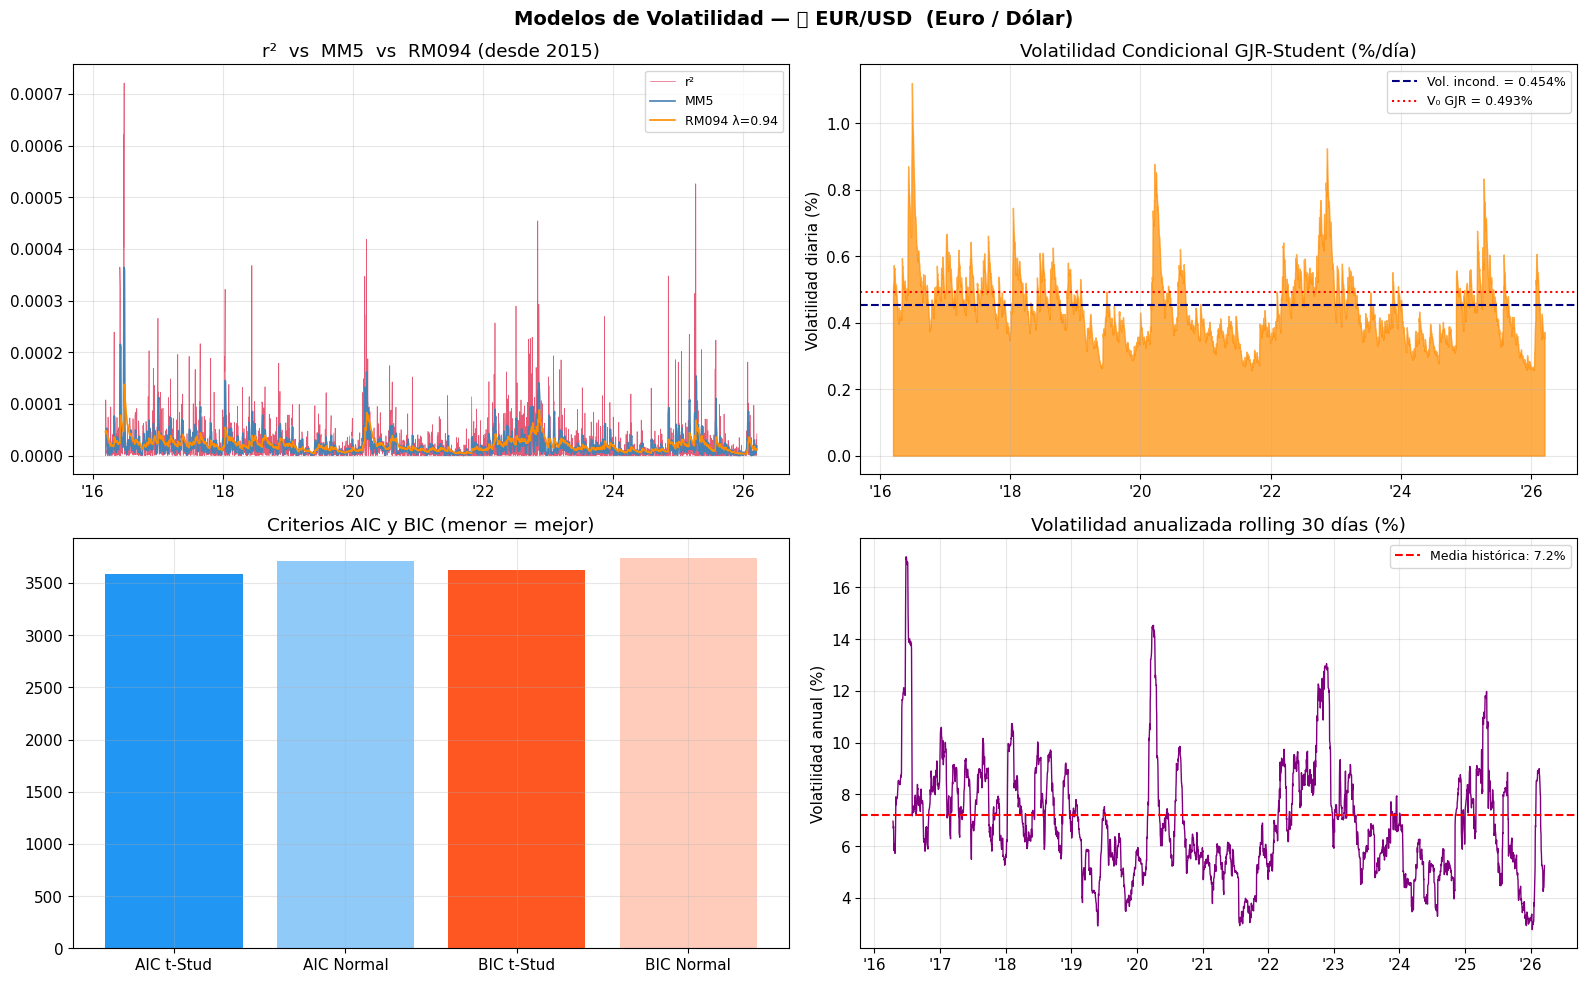

In [4]:
if not G or 'sq_r' not in G:
    print('⚠️  Ejecuta el bloque anterior primero.')
else:
    df   = G['df']
    r    = df['return']
    sq_r = G['sq_r']
    name = G['main_name']

    # ── MM5 ──────────────────────────────────────────────────────
    MM5 = sq_r.rolling(window=5).mean()

    # ── RM094 (λ=0.94) ───────────────────────────────────────────
    lam = 0.94
    rm  = np.zeros(len(sq_r))
    rm[0] = sq_r.iloc[0]
    for i in range(1, len(sq_r)):
        rm[i] = lam * rm[i-1] + (1-lam) * sq_r.iloc[i-1]
    RM094 = pd.Series(rm, index=sq_r.index)

    df['sq_r']  = sq_r
    df['MM5']   = MM5
    df['RM094'] = RM094
    G['df']     = df

    # ── GJR-GARCH t-Student ──────────────────────────────────────
    print('⏳ Estimando GJR-GARCH t-Student...')
    r100  = r * 100
    mod_t = arch_model(r100, vol='GARCH', p=1, o=1, q=1, dist='t', mean='Constant')
    res_t = mod_t.fit(disp='off', show_warning=False)
    print('✅ Estimación completada.')

    # ── GJR-GARCH Normal ─────────────────────────────────────────
    print('⏳ Estimando GJR-GARCH Normal...')
    mod_n = arch_model(r100, vol='GARCH', p=1, o=1, q=1, dist='normal', mean='Constant')
    res_n = mod_n.fit(disp='off', show_warning=False)
    print('✅ Estimación completada.')

    G['res_t'] = res_t
    G['res_n'] = res_n

    # ── Extraer parámetros ───────────────────────────────────────
    def extract(res):
        p   = res.params
        pv  = res.pvalues
        zv  = res.tvalues
        omega = p['omega'] / 10000
        alpha = p['alpha[1]']
        gamma = p['gamma[1]']
        beta  = p['beta[1]']
        denom = 1 - alpha - gamma/2 - beta
        V0    = (omega / denom) if denom > 0 else np.nan
        dof   = p.get('nu', np.nan)
        return dict(omega=omega, alpha=alpha, gamma=gamma, beta=beta,
                    V0=V0, dof=dof,
                    llik=res.loglikelihood, aic=res.aic, bic=res.bic,
                    pv_o=pv['omega'], pv_a=pv['alpha[1]'],
                    pv_g=pv['gamma[1]'], pv_b=pv['beta[1]'],
                    persist=alpha+gamma/2+beta)

    pt = extract(res_t)
    pn = extract(res_n)
    G['pt']  = pt
    G['pn']  = pn
    G['dof'] = pt['dof'] if not np.isnan(pt['dof']) else 5.0

    # Volatilidad condicional en escala original
    vol_cond = pd.Series(
        res_t.conditional_volatility.values / 100,
        index=df.index[-len(res_t.conditional_volatility):])
    var_cond = vol_cond ** 2
    G['vol_cond'] = vol_cond
    G['var_cond'] = var_cond

    # ── TABLA DE PARÁMETROS ──────────────────────────────────────
    print()
    print('📋 TABLA — Estimación GJR-GARCH')
    print('='*90)
    print(f'  {"":<12}{"ω (omega)":>14}{"α (alpha)":>12}{"γ (gamma)":>12}{"β (beta)":>10}'
          f'{"Persist.":>10}{"V0":>10}{"dof":>7}{"AIC":>14}')
    print('-'*90)
    for lab, p in [('t-Student', pt), ('Normal', pn)]:
        dof_s = f"{p['dof']:.3f}" if not np.isnan(p['dof']) else '  —  '
        print(f"  {lab:<12}{p['omega']:>14.8f}{p['alpha']:>12.6f}{p['gamma']:>12.6f}"
              f"{p['beta']:>10.6f}{p['persist']:>10.6f}{p['V0']:>10.6f}{dof_s:>7}{p['aic']:>14.4f}")
    print('='*90)

    print('\n💡 INTERPRETACIÓN GARCH EN FOREX:')
    print(f'  • Persistencia {pt["persist"]:.4f}: los shocks de volatilidad tardan '
          f'{1/(1-pt["persist"]):.0f} días en disiparse a la mitad')
    print(f'  • γ={pt["gamma"]:.4f}: {"las depreciaciones generan MÁS volatilidad que las apreciaciones (efecto apalancamiento)" if pt["gamma"]>0 else "sin asimetría significativa"}')
    print(f'  • V0={pt["V0"]:.6f} → volatilidad incondicional de largo plazo = {np.sqrt(pt["V0"])*100:.4f}%/día')
    print(f'  • dof={pt["dof"]:.2f}: cuanto menor, más colas pesadas → más eventos extremos')

    # ── Medias de los modelos ────────────────────────────────────
    Incond = r.std()
    print(f'\n📊 MEDIAS DE VOLATILIDAD (aprox. a varianza incondicional):')
    print(f'  Media r²        : {sq_r.mean():.8f}  →  vol. {np.sqrt(sq_r.mean())*100:.4f}%/día')
    print(f'  Media MM5       : {MM5.dropna().mean():.8f}  →  vol. {np.sqrt(MM5.dropna().mean())*100:.4f}%/día')
    print(f'  Media RM094     : {RM094.mean():.8f}  →  vol. {np.sqrt(RM094.mean())*100:.4f}%/día')
    print(f'  Vol. incond. σ  : {Incond:.8f}  →  vol. {Incond*100:.4f}%/día  |  {Incond*np.sqrt(252)*100:.2f}% anual')

    # ── GRÁFICOS ─────────────────────────────────────────────────
    mask = df.index >= '2015-01-01'
    idx_cv = vol_cond.index

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Modelos de Volatilidad — {name}', fontsize=14, fontweight='bold')

    # r², MM5, RM094 superpuestos
    axes[0,0].plot(df.index[mask], sq_r[mask],   color='crimson',    lw=0.5, alpha=0.7, label='r²')
    axes[0,0].plot(df.index[mask], MM5[mask],    color='steelblue',  lw=1.2, label='MM5')
    axes[0,0].plot(df.index[mask], RM094[mask],  color='darkorange', lw=1.2, label='RM094 λ=0.94')
    axes[0,0].set_title('r²  vs  MM5  vs  RM094 (desde 2015)')
    axes[0,0].legend(fontsize=9)
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # Volatilidad condicional GJR
    axes[0,1].fill_between(idx_cv, vol_cond.values * 100, color='darkorange', alpha=0.7)
    axes[0,1].axhline(Incond * 100, color='navy', lw=1.5, ls='--',
                      label=f'Vol. incond. = {Incond*100:.3f}%')
    axes[0,1].axhline(np.sqrt(pt['V0']) * 100, color='red', lw=1.5, ls=':',
                      label=f'V₀ GJR = {np.sqrt(pt["V0"])*100:.3f}%')
    axes[0,1].set_title('Volatilidad Condicional GJR-Student (%/día)')
    axes[0,1].set_ylabel('Volatilidad diaria (%)')
    axes[0,1].legend(fontsize=9)
    axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # AIC/BIC comparativo
    axes[1,0].bar(['AIC t-Stud', 'AIC Normal', 'BIC t-Stud', 'BIC Normal'],
                  [pt['aic'], pn['aic'], pt['bic'], pn['bic']],
                  color=['#2196F3','#90CAF9','#FF5722','#FFCCBC'])
    axes[1,0].set_title('Criterios AIC y BIC (menor = mejor)')

    # Volatilidad anualizada rolling 30 días
    vol_roll30 = r.rolling(30).std() * np.sqrt(252) * 100
    axes[1,1].plot(df.index, vol_roll30, color='purple', lw=1)
    axes[1,1].axhline(Incond*np.sqrt(252)*100, color='red', ls='--', lw=1.5,
                      label=f'Media histórica: {Incond*np.sqrt(252)*100:.1f}%')
    axes[1,1].set_title('Volatilidad anualizada rolling 30 días (%)')
    axes[1,1].set_ylabel('Volatilidad anual (%)')
    axes[1,1].legend(fontsize=9)
    axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    plt.tight_layout()
    plt.show()

---
## — VaR y Expected Shortfall (ES / CVaR)

### ¿Qué es el VaR en Forex?

Si tienes **10.000€ invertidos en EUR/USD** y el VaR al 1% es **0.80%**, significa:
> *"Con un 99% de confianza, mañana no perderé más de 80€ en este par"*

El **ES (Expected Shortfall)** te dice: *"Si ese 1% peor ocurre de verdad, ¿cuánto perderé en promedio?"* → siempre es mayor que el VaR.

### Los 4 métodos:

| Método | Cómo funciona | Ventaja | Limitación |
|--------|--------------|---------|------------|
| **Histórico** | Percentil de datos reales | Sin supuestos | Depende del período |
| **Normal** | Asume distribución Normal | Sencillo | Subestima cola izquierda |
| **t-Student** | Colas más pesadas que Normal | Más realista | Necesita estimar dof |
| **Monte Carlo** | Simula 100.000 escenarios con GJR | Más conservador | Computacionalmente costoso |

In [ ]:
if 'pt' not in G:
    print('⚠️  Ejecuta el bloque anterior primero.')
else:
    df       = G['df']
    r        = df['return']
    mu       = G['mu']
    sigma    = G['sigma']
    dof      = G['dof']
    vol_cond = G['vol_cond']
    pt       = G['pt']
    name     = G['main_name']

    last_vol = vol_cond.iloc[-1]

    taus  = [0.01, 0.025]
    RES   = {}

    for tau in taus:
        # ── HISTÓRICO ─────────────────────────────────────────────
        VaR_H = -np.percentile(r, tau*100)
        ES_H  = -r[r <= -VaR_H].mean()

        # ── PARAMÉTRICO NORMAL ────────────────────────────────────
        z_q    = norm.ppf(tau)
        VaR_N  = -mu - sigma * z_q
        ES_N   = -mu + sigma * norm.pdf(z_q) / tau

        # ── PARAMÉTRICO t-STUDENT (dinámico con GJR) ──────────────
        t_q    = t_dist.ppf(tau, df=dof)
        scale  = sigma * np.sqrt((dof-2)/dof)          # estático
        VaR_Pt = -mu - scale * t_q
        fd_t   = t_dist.pdf(t_q, df=dof)
        ES_Pt  = -mu + scale * (1/tau) * (1/(dof-1)) * (dof + t_q**2) * fd_t

        # ── MONTE CARLO (con última vol. condicional GJR) ─────────
        np.random.seed(12345)
        z_sim  = t_dist.rvs(df=dof, size=100_000)
        r_sim  = mu + last_vol * z_sim
        VaR_MC = -np.percentile(r_sim, tau*100)
        ES_MC  = -r_sim[r_sim <= -VaR_MC].mean()

        RES[tau] = dict(VaR_H=VaR_H,  ES_H=ES_H,
                        VaR_N=VaR_N,   ES_N=ES_N,
                        VaR_Pt=VaR_Pt, ES_Pt=ES_Pt,
                        VaR_MC=VaR_MC, ES_MC=ES_MC)

    G['RES'] = RES

    # ── TABLA 3 ──────────────────────────────────────────────────
    print(f'📋 VaR y ES — {name}')
    print('='*65)
    print(f'  {"Método":<28}{"VaR 1%":>10}{"ES 1%":>10}{"VaR 2.5%":>10}{"ES 2.5%":>10}')
    print('-'*65)
    filas = [
        ('Histórico',       'VaR_H',  'ES_H'),
        ('Normal',          'VaR_N',  'ES_N'),
        ('t-Student (GJR)', 'VaR_Pt', 'ES_Pt'),
        ('Monte Carlo',     'VaR_MC', 'ES_MC'),
    ]
    for lab, kv, ke in filas:
        v1  = RES[0.01][kv];  e1  = RES[0.01][ke]
        v25 = RES[0.025][kv]; e25 = RES[0.025][ke]
        print(f'  {lab:<28}{v1:>10.6f}{e1:>10.6f}{v25:>10.6f}{e25:>10.6f}')
    print('='*65)

    cap = 10000
    print(f'\n💰 TRADUCCIÓN A EUROS (capital = {cap:,.0f}€):')
    print(f'  VaR 1% Histórico    → pérdida máxima: {RES[0.01]["VaR_H"]*cap:>8.2f}€')
    print(f'  ES  1% Histórico    → pérdida esperada si se supera: {RES[0.01]["ES_H"]*cap:>8.2f}€')
    print(f'  VaR 1% Monte Carlo  → pérdida máxima: {RES[0.01]["VaR_MC"]*cap:>8.2f}€  (más conservador)')

    # ── VaR dinámico ─────────────────────────────────────────────
    idx_cv  = vol_cond.index
    r_al    = r.reindex(idx_cv)

    def dyn_var_es(vol_s, tau):
        t_q  = t_dist.ppf(tau, df=dof)
        fd_t = t_dist.pdf(t_q, df=dof)
        sc   = vol_s * np.sqrt((dof-2)/dof)
        VaR  = -mu - sc * t_q
        ES   = -mu + sc * (1/tau) * (1/(dof-1)) * (dof + t_q**2) * fd_t
        return VaR, ES

    VaR_d01, ES_d01   = dyn_var_es(vol_cond, 0.01)
    VaR_d025, ES_d025 = dyn_var_es(vol_cond, 0.025)
    G['VaR_d01']  = VaR_d01
    G['ES_d01']   = ES_d01
    G['VaR_d025'] = VaR_d025
    G['r_al']     = r_al

    # ── GRÁFICOS ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'VaR y ES — {name}', fontweight='bold')

    for ax, tau, tlab in zip(axes, [0.01, 0.025], ['1%', '2.5%']):
        mets = ['Hist.', 'Normal', 't-Stud', 'MC']
        vs = [RES[tau]['VaR_H'], RES[tau]['VaR_N'], RES[tau]['VaR_Pt'], RES[tau]['VaR_MC']]
        es = [RES[tau]['ES_H'],  RES[tau]['ES_N'],  RES[tau]['ES_Pt'],  RES[tau]['ES_MC']]
        x  = np.arange(4)
        ax.bar(x-0.2, vs, 0.35, label='VaR', color='steelblue')
        ax.bar(x+0.2, es, 0.35, label='ES',  color='crimson')
        ax.set_xticks(x); ax.set_xticklabels(mets)
        ax.set_title(f'VaR y ES al {tlab}', fontweight='bold')
        ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Gráfico dinámico ─────────────────────────────────────────
    for tau_v, VaR_d, ES_d, tlab in [
        (0.01, VaR_d01, ES_d01, '1%'), (0.025, VaR_d025, ES_d025, '2.5%')]:
        fig, ax = plt.subplots(figsize=(16, 5))
        ax.plot(r_al.index, r_al.values, color='crimson', lw=0.5, alpha=0.8, label='rₜ')
        ax.plot((-VaR_d).index, (-VaR_d).values, color='green',     lw=1.3, label=f'−VaR {tlab}')
        ax.plot((-ES_d).index,  (-ES_d).values,  color='blueviolet',lw=1.3, label=f'−ES {tlab}')
        ax.axhline(0, color='black', lw=0.7)
        ax.set_title(f'Rendimientos, −VaR y −ES dinámicos al {tlab} — {name}', fontweight='bold')
        ax.legend()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.tight_layout()
        plt.show()

---
## — Drawdown, Sharpe, Sortino y Calmar

### ¿Por qué estas métricas en Forex?

El VaR mide el riesgo de **un día**. Pero en Forex, también importa:
- ¿Cuánto he perdido acumulado desde el máximo? → **Max Drawdown**
- ¿El par me compensa el riesgo que asumo? → **Sharpe Ratio**
- ¿Penalizo solo las pérdidas, no la volatilidad al alza? → **Sortino Ratio**
- ¿Cuánto rindo por unidad de drawdown máximo? → **Calmar Ratio**

| Ratio | Fórmula | Interpretación |
|-------|---------|----------------|
| **Sharpe** | $(\mu_r - r_f) / \sigma$ anualizados | >1 es bueno; >2 es excelente |
| **Sortino** | $(\mu_r - r_f) / \sigma_{downside}$ | Solo penaliza pérdidas |
| **Calmar** | Rendimiento anual / Max Drawdown | >1 es aceptable |
| **Max DD** | Peor caída desde un máximo | Cuánto puede perderse en la peor racha |

> 💡 En Forex puro (sin apalancamiento), los ratios son bajos porque los rendimientos diarios son muy pequeños. Con apalancamiento x10, se multiplican también las pérdidas.

In [ ]:
if 'RES' not in G:
    print('⚠️  Ejecuta el bloque anterior primero.')
else:
    df   = G['df']
    r    = df['return']
    mu   = G['mu']
    sigma= G['sigma']
    name = G['main_name']
    rf   = 0.0   # tasa libre de riesgo diaria (0 para simplificar)

    # ── Drawdown ─────────────────────────────────────────────────
    price     = df['price']
    roll_max  = price.cummax()
    drawdown  = (price - roll_max) / roll_max
    max_dd    = drawdown.min()          # número negativo
    max_dd_dt = drawdown.idxmin()

    # Fecha del máximo previo al drawdown máximo
    max_dt    = price[:max_dd_dt].idxmax()

    # ── Sharpe ───────────────────────────────────────────────────
    ann_ret   = mu * 252
    ann_vol   = sigma * np.sqrt(252)
    sharpe    = (ann_ret - rf * 252) / ann_vol

    # ── Sortino ──────────────────────────────────────────────────
    downside  = r[r < rf]
    sigma_down= downside.std() * np.sqrt(252)
    sortino   = (ann_ret - rf * 252) / sigma_down if sigma_down > 0 else np.nan

    # ── Calmar ───────────────────────────────────────────────────
    calmar    = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    # ── VaR anualizado ───────────────────────────────────────────
    VaR_ann   = G['RES'][0.01]['VaR_Pt'] * np.sqrt(252)

    G['metrics'] = dict(sharpe=sharpe, sortino=sortino, calmar=calmar,
                         max_dd=max_dd, ann_ret=ann_ret, ann_vol=ann_vol)

    print(f'📋 MÉTRICAS DE RIESGO Y RENDIMIENTO — {name}')
    print('='*60)
    print(f'  Rendimiento anualizado    : {ann_ret*100:>8.4f}%')
    print(f'  Volatilidad anualizada    : {ann_vol*100:>8.4f}%')
    print(f'  VaR 1% anualizado (√252)  : {VaR_ann*100:>8.4f}%')
    print('  ─'*30)
    print(f'  Sharpe Ratio              : {sharpe:>8.4f}')
    print(f'  Sortino Ratio             : {sortino:>8.4f}')
    print(f'  Calmar Ratio              : {calmar:>8.4f}')
    print('  ─'*30)
    print(f'  Max Drawdown              : {max_dd*100:>8.4f}%  (el {max_dd_dt.date()})')
    print(f'  Máximo previo             : el {max_dt.date()}')
    print(f'  Duración del drawdown     : {(max_dd_dt - max_dt).days} días')
    print('='*60)

    # Interpretación
    print('\n💡 INTERPRETACIÓN:')
    print(f'  Sharpe {sharpe:.3f}: ', end='')
    if sharpe > 1:   print('Excelente — el par compensa bien su riesgo')
    elif sharpe > 0: print('Positivo pero moderado — el par da algo más que el riesgo asumido')
    else:            print('Negativo — el par no compensa el riesgo en este período')

    print(f'  Sortino {sortino:.3f}: penaliza SOLO las pérdidas (más justo que Sharpe)')
    print(f'  Max DD {max_dd*100:.2f}%: en el peor momento histórico, el tipo de cambio')
    print(f'   cayó un {abs(max_dd)*100:.2f}% desde su máximo previo durante {(max_dd_dt-max_dt).days} días')

    # ── GRÁFICOS ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    fig.suptitle(f'Drawdown y Ratios — {name}', fontsize=14, fontweight='bold')

    # Precio + drawdown
    axes[0,0].plot(price.index, price, color='steelblue', lw=0.8)
    axes[0,0].plot(roll_max.index, roll_max, color='gray', lw=0.8, ls='--', alpha=0.5, label='Máximo histórico')
    axes[0,0].axvline(max_dt,    color='green', lw=1.5, ls='--', label=f'Máximo ({max_dt.date()})')
    axes[0,0].axvline(max_dd_dt, color='red',   lw=1.5, ls='--', label=f'Fondo DD ({max_dd_dt.date()})')
    axes[0,0].set_title('Precio + Máximo acumulado')
    axes[0,0].legend(fontsize=8)
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # Drawdown
    axes[0,1].fill_between(drawdown.index, drawdown.values * 100,
                            0, color='crimson', alpha=0.5)
    axes[0,1].axhline(max_dd*100, color='darkred', lw=1.5, ls='--',
                       label=f'Max DD = {max_dd*100:.2f}%')
    axes[0,1].set_title('Drawdown (% desde máximo histórico)')
    axes[0,1].set_ylabel('%')
    axes[0,1].legend()
    axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # Ratios
    ratios_vals  = [sharpe, sortino, calmar]
    ratios_names = ['Sharpe', 'Sortino', 'Calmar']
    colors_r = ['#2196F3' if v > 0 else '#F44336' for v in ratios_vals]
    axes[1,0].bar(ratios_names, ratios_vals, color=colors_r, alpha=0.85)
    axes[1,0].axhline(0, color='black', lw=0.8)
    axes[1,0].axhline(1, color='green', lw=1, ls='--', label='Umbral = 1')
    axes[1,0].set_title('Ratios de rendimiento/riesgo')
    axes[1,0].legend()

    # Rendimiento acumulado
    cum_ret = (1 + r).cumprod()
    axes[1,1].plot(cum_ret.index, cum_ret, color='steelblue', lw=1)
    axes[1,1].axhline(1, color='black', lw=0.7)
    axes[1,1].set_title('Rendimiento acumulado (base 1)')
    axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    plt.tight_layout()
    plt.show()

---
## — Correlaciones entre pares de divisas

### ¿Por qué importa la correlación en Forex?

Si tienes varias posiciones abiertas en Forex, la correlación entre pares determina si **realmente estás diversificando** o si en realidad tienes el mismo riesgo dos veces.

**Ejemplos típicos:**
- **EUR/USD y GBP/USD**: correlación ~0.85 → si el dólar sube, ambos caen juntos. Tener los dos NO es diversificar.
- **EUR/USD y USD/CHF**: correlación ~-0.90 → movimientos opuestos. Tener ambos casi se cancela.
- **EUR/USD y AUD/USD**: correlación ~0.60 → moderada. Algo de diversificación.

> 💡 **Regla de trading**: Si dos pares tienen correlación >0.8 o <-0.8, son básicamente el mismo trade. Evita tener ambos con el mismo tamaño de posición.

In [ ]:
if 'multi' not in G or len(G['multi']) < 2:
    print('⚠️  Selecciona al menos 2 pares en el Bloque 0.')
else:
    multi = G['multi']

    # ── Construir DataFrame de rendimientos ──────────────────────
    ret_dict = {}
    for nm, df_i in multi.items():
        short = nm.split('(')[0].strip().replace('🟢 ','').replace('🟡 ','').replace('🔴 ','')
        ret_dict[short] = df_i['return']

    ret_df = pd.DataFrame(ret_dict).dropna()
    G['ret_df'] = ret_df

    corr = ret_df.corr()

    print('📋 MATRIZ DE CORRELACIONES (rendimientos diarios)')
    print('  Interpretación: 1.0=movimiento idéntico | 0=independientes | -1.0=movimiento opuesto')
    print()
    print(corr.round(3).to_string())

    # ── Pares altamente correlacionados ──────────────────────────
    print('\n🔴 CORRELACIONES ALTAS (|corr|>0.7) — riesgo de doble exposición:')
    found = False
    cols = list(corr.columns)
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c = corr.iloc[i,j]
            if abs(c) > 0.7:
                tipo = '⚠️  MISMA dirección' if c > 0 else '🔄 OPUESTA dirección'
                print(f'  {cols[i]} vs {cols[j]}: {c:.3f}  {tipo}')
                found = True
    if not found:
        print('  Ningún par supera el umbral de 0.7 en este grupo.')

    # ── HEATMAP ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Análisis de Correlaciones — Pares Forex', fontsize=14, fontweight='bold')

    # Heatmap
    mask_tri = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=-1, vmax=1, linewidths=0.5,
                annot_kws={'size': 9})
    axes[0].set_title('Matriz de Correlaciones\n(verde=correlación positiva, rojo=negativa)')

    # Volatilidades comparadas
    vols = {}
    for nm, df_i in multi.items():
        short = nm.split('(')[0].strip().replace('🟢 ','').replace('🟡 ','').replace('🔴 ','')
        ann_v = df_i['return'].std() * np.sqrt(252) * 100
        vols[short] = ann_v

    vols_s = dict(sorted(vols.items(), key=lambda x: x[1], reverse=True))
    colors_v = ['#F44336' if v > 10 else '#FF9800' if v > 6 else '#4CAF50'
                for v in vols_s.values()]
    axes[1].barh(list(vols_s.keys()), list(vols_s.values()), color=colors_v, alpha=0.85)
    axes[1].axvline(6,  color='orange', lw=1.5, ls='--', label='Umbral moderado (6%)')
    axes[1].axvline(10, color='red',    lw=1.5, ls='--', label='Umbral alto (10%)')
    axes[1].set_title('Volatilidad anualizada por par\n(🟢<6%  🟠6-10%  🔴>10%)')
    axes[1].set_xlabel('Volatilidad anualizada (%)')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

---
##  Filtrador: Ranking de Pares por Riesgo

### ¿Cómo funciona el filtrador?

Calculamos automáticamente **5 métricas de riesgo** para todos los pares seleccionados y los ordenamos de **menor a mayor riesgo**. Puedes elegir por qué métrica ordenar.

Esto responde a la pregunta: *"¿En qué par debería entrar si quiero minimizar el riesgo hoy?"*

| Métrica | Qué mide | Menor = Mejor |
|---------|---------|---------------|
| **Vol. anual** | Riesgo histórico total | ✅ |
| **VaR 1%** | Pérdida máxima esperada mañana | ✅ |
| **ES 1%** | Pérdida esperada en escenario extremo | ✅ |
| **Max Drawdown** | Peor caída histórica | ✅ |
| **Sharpe** | Rendimiento por unidad de riesgo | ❌ (mayor = mejor) |

In [ ]:
if 'multi' not in G:
    print('⚠️  Ejecuta el Bloque 0 primero.')
else:
    multi = G['multi']
    rows  = []

    print('⏳ Calculando métricas para todos los pares seleccionados...')
    for nm, df_i in multi.items():
        short = nm.split('(')[0].strip().replace('🟢 ','').replace('🟡 ','').replace('🔴 ','')
        emoji = '🟢' if '🟢' in nm else '🟡' if '🟡' in nm else '🔴'
        r_i   = df_i['return'].dropna()
        try:
            mu_i    = r_i.mean()
            sig_i   = r_i.std()
            ann_vol = sig_i * np.sqrt(252) * 100
            ann_ret = mu_i  * 252 * 100

            # VaR y ES histórico al 1%
            VaR_h1 = -np.percentile(r_i, 1) * 100
            ES_h1  = -r_i[r_i <= np.percentile(r_i, 1)].mean() * 100

            # Max Drawdown
            px = df_i['price']
            dd = ((px - px.cummax()) / px.cummax()).min() * 100

            # Sharpe
            sharpe = (ann_ret / 100) / (ann_vol / 100) if ann_vol > 0 else np.nan

            # Sortino
            dn = r_i[r_i < 0].std() * np.sqrt(252)
            sortino = (ann_ret/100) / dn if dn > 0 else np.nan

            rows.append({
                'Par': f'{emoji} {short}',
                'Vol. Anual %': round(ann_vol, 4),
                'Rend. Anual %': round(ann_ret, 4),
                'VaR 1% %': round(VaR_h1, 4),
                'ES 1% %': round(ES_h1, 4),
                'Max DD %': round(abs(dd), 4),
                'Sharpe': round(sharpe, 4),
                'Sortino': round(sortino, 4),
            })
        except:
            pass

    ranking_df = pd.DataFrame(rows)
    G['ranking_df'] = ranking_df

    # ── Widget de ordenación ──────────────────────────────────────
    sort_options = {
        'Vol. Anualizada (menor=menos riesgo)': ('Vol. Anual %', True),
        'VaR 1% (menor=menos riesgo)':          ('VaR 1% %', True),
        'ES 1% (menor=menos riesgo)':           ('ES 1% %', True),
        'Max Drawdown (menor=menos riesgo)':    ('Max DD %', True),
        'Sharpe Ratio (mayor=mejor)':           ('Sharpe', False),
        'Sortino Ratio (mayor=mejor)':          ('Sortino', False),
    }

    dd_sort  = widgets.Dropdown(
        options=list(sort_options.keys()),
        description='Ordenar por:',
        style={'description_width': '110px'},
        layout=widgets.Layout(width='400px')
    )
    btn_sort = widgets.Button(description='📊 Mostrar ranking',
                               button_style='info',
                               layout=widgets.Layout(width='180px'))
    out_sort = widgets.Output()

    def show_ranking(b):
        with out_sort:
            clear_output()
            col, asc = sort_options[dd_sort.value]
            df_sorted = ranking_df.sort_values(col, ascending=asc).reset_index(drop=True)
            df_sorted.index += 1

            print(f'\n🏆 RANKING DE PARES — Ordenado por: {dd_sort.value}')
            print('='*90)
            print(df_sorted.to_string())
            print('='*90)

            # Gráficos
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f'Ranking de Pares — {dd_sort.value}', fontweight='bold')

            pairs_s = df_sorted['Par'].tolist()
            colors_rank = ['#4CAF50' if '🟢' in p else '#FF9800' if '🟡' in p else '#F44336'
                           for p in pairs_s]

            # Vol. anual
            axes[0].barh(pairs_s, df_sorted['Vol. Anual %'], color=colors_rank, alpha=0.8)
            axes[0].set_title('Volatilidad Anualizada (%)')
            axes[0].invert_yaxis()
            axes[0].axvline(6,  color='orange', lw=1, ls='--')
            axes[0].axvline(10, color='red',    lw=1, ls='--')

            # VaR y ES
            x_pos = np.arange(len(pairs_s))
            axes[1].bar(x_pos-0.2, df_sorted['VaR 1% %'], 0.35, label='VaR 1%', color='steelblue', alpha=0.8)
            axes[1].bar(x_pos+0.2, df_sorted['ES 1% %'],  0.35, label='ES 1%',  color='crimson',   alpha=0.8)
            axes[1].set_xticks(x_pos)
            axes[1].set_xticklabels(
                [p.split('/')[0].split(' ')[-1]+'/'+p.split('/')[1].split(' ')[0]
                 if '/' in p else p for p in pairs_s],
                rotation=45, fontsize=8)
            axes[1].set_title('VaR y ES al 1% (%)')
            axes[1].legend()

            # Sharpe
            colors_sh = ['#4CAF50' if v > 0 else '#F44336' for v in df_sorted['Sharpe']]
            axes[2].bar(x_pos, df_sorted['Sharpe'], color=colors_sh, alpha=0.8)
            axes[2].axhline(0, color='black', lw=0.8)
            axes[2].axhline(1, color='green', lw=1, ls='--', label='Umbral 1')
            axes[2].set_xticks(x_pos)
            axes[2].set_xticklabels(
                [p.split('/')[0].split(' ')[-1]+'/'+p.split('/')[1].split(' ')[0]
                 if '/' in p else p for p in pairs_s],
                rotation=45, fontsize=8)
            axes[2].set_title('Sharpe Ratio')
            axes[2].legend()

            plt.tight_layout()
            plt.show()

            # Recomendación
            safest  = df_sorted.iloc[0]['Par']
            riskiest= df_sorted.iloc[-1]['Par']
            print(f'\n  🟢 Menos riesgo según {col}: {safest}')
            print(f'  🔴 Más riesgo  según {col}: {riskiest}')
            print(f'\n  💡 Recuerda: menor volatilidad ≠ mejor par. Un par exótico con Sharpe')
            print(f'     alto puede compensar mejor el riesgo que un major aburrido con Sharpe bajo.')

    btn_sort.on_click(show_ranking)
    display(HTML('<h4>Elige el criterio de ordenación del ranking:</h4>'))
    display(widgets.HBox([dd_sort, btn_sort]))
    display(out_sort)
    print('\n⬆️  Selecciona un criterio y pulsa "Mostrar ranking"')

---
##  Test de Kupiec + Backtesting del VaR

In [ ]:
if 'VaR_d01' not in G:
    print('⚠️  Ejecuta el Bloque 3 primero.')
else:
    r_al    = G['r_al']
    VaR_d01 = G['VaR_d01']
    RES     = G['RES']
    sigma   = G['sigma']
    mu      = G['mu']
    name    = G['main_name']
    T       = len(r_al)

    def kupiec(n_viol, T, tau):
        if n_viol == 0 or n_viol == T: return np.nan, np.nan
        p_hat = n_viol / T
        num   = tau**n_viol   * (1-tau)**(T-n_viol)
        den   = p_hat**n_viol * (1-p_hat)**(T-n_viol)
        LR    = -2 * np.log(num / den)
        pval  = 1 - stats.chi2.cdf(LR, df=1)
        return LR, pval

    # VaR Normal estático
    VaR_N_01 = pd.Series(-mu - sigma * norm.ppf(0.01), index=r_al.index)

    modelos_kup = [
        ('GJR t-Student (τ=1%)', VaR_d01, 0.01),
        ('Normal estático (τ=1%)', VaR_N_01, 0.01),
    ]

    print(f'📋 BACKTESTING KUPIEC — {name}')
    print(f'  T = {T} observaciones  |  Violaciones esperadas al 1%: {T*0.01:.1f}')
    print('='*75)
    print(f'  {"Modelo":<28}{"# Viol":>8}{"% Viol":>10}{"Esperadas":>11}{"LR":>10}{"P-valor":>10}')
    print('-'*75)

    for lab, VaR_s, tau in modelos_kup:
        n_viol = (r_al < -VaR_s).sum()
        pct    = n_viol / T
        LR, pv = kupiec(n_viol, T, tau)
        print(f'  {lab:<28}{n_viol:>8}{pct:>10.6f}{T*tau:>11.1f}'
              f'{LR:>10.4f}{pv:>10.6f}')
        print(f'  {"":>28}  → ', end='')
        if pv is None or np.isnan(pv): print('N/A')
        elif pv <= 0.01:  print(f'❌ RECHAZA al 1% (p={pv:.4f}) → modelo subestima el riesgo')
        elif pv <= 0.05:  print(f'⚠️  RECHAZA al 5% (p={pv:.4f}) → modelo mejorable')
        else:             print(f'✅ Aceptable (p={pv:.4f}) → el modelo calibra bien')

    print('='*75)

    # ── Gráfico violaciones ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(r_al.index, r_al.values, color='gray', lw=0.5, alpha=0.7, label='rₜ')
    ax.plot((-VaR_d01).index, (-VaR_d01).values,
            color='green', lw=1.2, label='−VaR GJR-t 1%')
    mask_v = r_al < -VaR_d01
    ax.scatter(r_al.index[mask_v], r_al.values[mask_v],
               color='red', s=18, zorder=5, label=f'Violaciones ({mask_v.sum()})')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(f'Violaciones VaR 1% — {name}', fontweight='bold')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    print(f'\n💡 Las violaciones tienden a aparecer en CLUSTERS (COVID 2020, Flash crashes,...)')
    print(f'   Eso indica que el riesgo en Forex NO es constante → justifica el modelo GARCH.')

---
## Dashboard Visual Completo

In [ ]:
if 'RES' not in G:
    print('⚠️  Ejecuta todos los pasos anteriores primero.')
else:
    df        = G['df']
    r         = df['return']
    pt        = G['pt']
    pn        = G['pn']
    RES       = G['RES']
    vol_cond  = G['vol_cond']
    VaR_d01   = G['VaR_d01']
    r_al      = G['r_al']
    mu        = G['mu']
    sigma     = G['sigma']
    metrics   = G.get('metrics', {})
    name      = G['main_name']
    symbol    = G['main_symbol']

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(f'📊 FOREX RISK DASHBOARD — {name} ({symbol})',
                 fontsize=17, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Precio
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df.index, df['price'], color='steelblue', lw=0.8)
    ax1.set_title('Tipo de cambio', fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 2. Rendimientos
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(df.index, r, color='crimson', lw=0.5, alpha=0.8)
    ax2.axhline(0, color='black', lw=0.7)
    ax2.set_title('Rendimientos rₜ', fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 3. Histograma
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(r, bins=100, color='steelblue', alpha=0.7, density=True)
    xr = np.linspace(r.min(), r.max(), 300)
    ax3.plot(xr, norm.pdf(xr, mu, sigma), 'r-', lw=2, label='Normal')
    ax3.axvline(-RES[0.01]['VaR_Pt'], color='purple', ls='--', lw=1.5, label='VaR 1%')
    ax3.set_title('Distribución + VaR 1%', fontweight='bold')
    ax3.legend(fontsize=8)

    # 4. r², MM5, RM094
    ax4 = fig.add_subplot(gs[1, 0])
    mask = df.index >= '2015-01-01'
    ax4.plot(df.index[mask], df['sq_r'][mask],  color='crimson',   lw=0.5, alpha=0.7, label='r²')
    ax4.plot(df.index[mask], df['MM5'][mask],   color='steelblue', lw=1.1, label='MM5')
    ax4.plot(df.index[mask], df['RM094'][mask], color='darkorange',lw=1.1, label='RM094')
    ax4.set_title('r²  MM5  RM094', fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 5. Volatilidad condicional GJR
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.fill_between(vol_cond.index, vol_cond.values * 100, color='darkorange', alpha=0.7)
    ax5.set_title('Vol. Condicional GJR-t (%)', fontweight='bold')
    ax5.xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # 6. VaR/ES comparativo
    ax6 = fig.add_subplot(gs[1, 2])
    mets  = ['Hist.', 'Normal', 't-Stud', 'MC']
    vs6   = [RES[0.01]['VaR_H'], RES[0.01]['VaR_N'], RES[0.01]['VaR_Pt'], RES[0.01]['VaR_MC']]
    es6   = [RES[0.01]['ES_H'],  RES[0.01]['ES_N'],  RES[0.01]['ES_Pt'],  RES[0.01]['ES_MC']]
    x6    = np.arange(4)
    ax6.bar(x6-0.2, vs6, 0.35, label='VaR 1%', color='steelblue')
    ax6.bar(x6+0.2, es6, 0.35, label='ES 1%',  color='crimson')
    ax6.set_xticks(x6); ax6.set_xticklabels(mets, fontsize=9)
    ax6.set_title('VaR y ES al 1%', fontweight='bold')
    ax6.legend(fontsize=8)

    # 7. Rendimientos + VaR dinámico + violaciones
    ax7 = fig.add_subplot(gs[2, 0:2])
    ax7.plot(r_al.index, r_al.values, color='gray', lw=0.4, alpha=0.7, label='rₜ')
    ax7.plot((-VaR_d01).index, (-VaR_d01).values, color='green', lw=1.1, label='−VaR 1%')
    mask_v = r_al < -VaR_d01
    ax7.scatter(r_al.index[mask_v], r_al.values[mask_v],
                color='red', s=10, zorder=5, label=f'Viol. ({mask_v.sum()})')
    ax7.axhline(0, color='black', lw=0.7)
    ax7.set_title(f'rₜ + −VaR 1% dinámico + Violaciones ({mask_v.sum()} de {T})', fontweight='bold')
    ax7.legend(fontsize=9)
    ax7.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # 8. Ratios y métricas resumen
    ax8 = fig.add_subplot(gs[2, 2])
    if metrics:
        r_names = ['Sharpe', 'Sortino', 'Calmar']
        r_vals  = [metrics.get('sharpe',0), metrics.get('sortino',0), metrics.get('calmar',0)]
        c_bars  = ['#4CAF50' if v > 0 else '#F44336' for v in r_vals]
        ax8.bar(r_names, r_vals, color=c_bars, alpha=0.85)
        ax8.axhline(0, color='black', lw=0.8)
        ax8.axhline(1, color='green', lw=1, ls='--')
        ax8.set_title(
            f'Ratios  |  Vol.Anual: {metrics.get("ann_vol",0)*100:.2f}%\n'
            f'MaxDD: {metrics.get("max_dd",0)*100:.2f}%  |  Ret.Anual: {metrics.get("ann_ret",0)*100:.2f}%',
            fontweight='bold', fontsize=9)
    else:
        ax8.text(0.5, 0.5, 'Ejecuta\nBloque 4', ha='center', va='center')

    plt.savefig('/content/forex_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n✅ Dashboard guardado en /content/forex_dashboard.png')
    print(f'\n📋 RESUMEN EJECUTIVO — {name} ({symbol})')
    print('='*55)
    print(f'  VaR 1%  t-Student (hoy)  : {RES[0.01]["VaR_Pt"]*100:.4f}%')
    print(f'  ES  1%  t-Student (hoy)  : {RES[0.01]["ES_Pt"]*100:.4f}%')
    print(f'  Vol. anualizada           : {sigma*np.sqrt(252)*100:.2f}%')
    print(f'  Persistencia GARCH        : {pt["persist"]:.4f}')
    if metrics:
        print(f'  Sharpe Ratio              : {metrics.get("sharpe",0):.4f}')
        print(f'  Max Drawdown histórico    : {metrics.get("max_dd",0)*100:.2f}%')
    print(f'  Violaciones VaR 1%        : {mask_v.sum()} / {T} ({mask_v.sum()/T*100:.2f}%)')
    print('='*55)